In [1]:
from DatabankLib.protein_functions import *
import yaml

databankPath = "/home/sosamuli/work/NMRlipids/IDPdatabank/"  # this is the local path for the cloned Databank
os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPdatabank/"


# These two lines include core Databank routines and Databank API
from DatabankLib.core import *
from DatabankLib.databankLibrary import *
# This is for plotting
from DatabankLib.databankio import *
from DatabankLib.plottings import plotSimulation
#from IPython.display import display, Markdown

# This initializes the databank and stores the information of all simulations into a list.
# Each list item contains the information from README.yaml file of the given simulation.
systems = initialize_databank()

/home/sosamuli/anaconda3/envs/IDPdatabank/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/sosamuli/anaconda3/envs/IDPdatabank/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


Databank initialized from the folder: /home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations


In [2]:
IDs = list(range(1, 25))
IDs.remove(23)

files = []

for system in systems:
    #print(system['TRJ'][0][0])
    try:
        if system['ID'] in IDs:
            dataFolder = '../../Data/Simulations/' + system['path'] + system['TRJ'][0][0]
            print(dataFolder)
    except:
        continue

../../Data/Simulations/f8e/81d/f8e81d87d1c190bc5ec45084165e12dec9ed5d13/c26e9d4317436c590fe19ecff68b36cdcc8508d9/replica_02_DESAMBER_md_2000ns.xtc
../../Data/Simulations/cdf/798/cdf7987102d6473c8ad0ab8a4f7c384b16b4cb5b/bab80edfd37192c8d2df12c5865f2c658d21a7d1/replica_03_AMBER99SBWS_md_1500ns.xtc
../../Data/Simulations/082/ab4/082ab4aadd4dcb08f1f8b5c27c7f7c4e0c592c55/b6b68bfc7e719eafc21ce452ff6f44d214769ce1/replica_03_AMBER03WS_md_1500ns.xtc
../../Data/Simulations/ead/ea4/eadea42c0c2e4be95ab0fdddf1bb8cb8f37f88bc/2147ba4d757f0218ab957ac602c5289659a36a26/replica_04_AMBER99SBWS_md_1500ns.xtc
../../Data/Simulations/179/10c/17910cbc3032e3d9e16b27a94981b9257bb11d7f/1f9c8d032d3a63752b73f579c5eed887e3534f5d/replica_01_DESAMBER_md_2000ns.xtc
../../Data/Simulations/a99/493/a99493b9f1af9649db5f09eae8a8d247316e6725/69cb47a60cbe364fef7e1596943b95f88c90e747/replica_05_AMBER03WS_md_1500ns.xtc
../../Data/Simulations/539/32c/53932c2fcab34bddd6649b442f9f060e1ab21eb9/2371e636a29194050519c5ae824420b89625ae

KRS1-72
[['replica_05_DESAMBER_md_2000ns.xtc']]


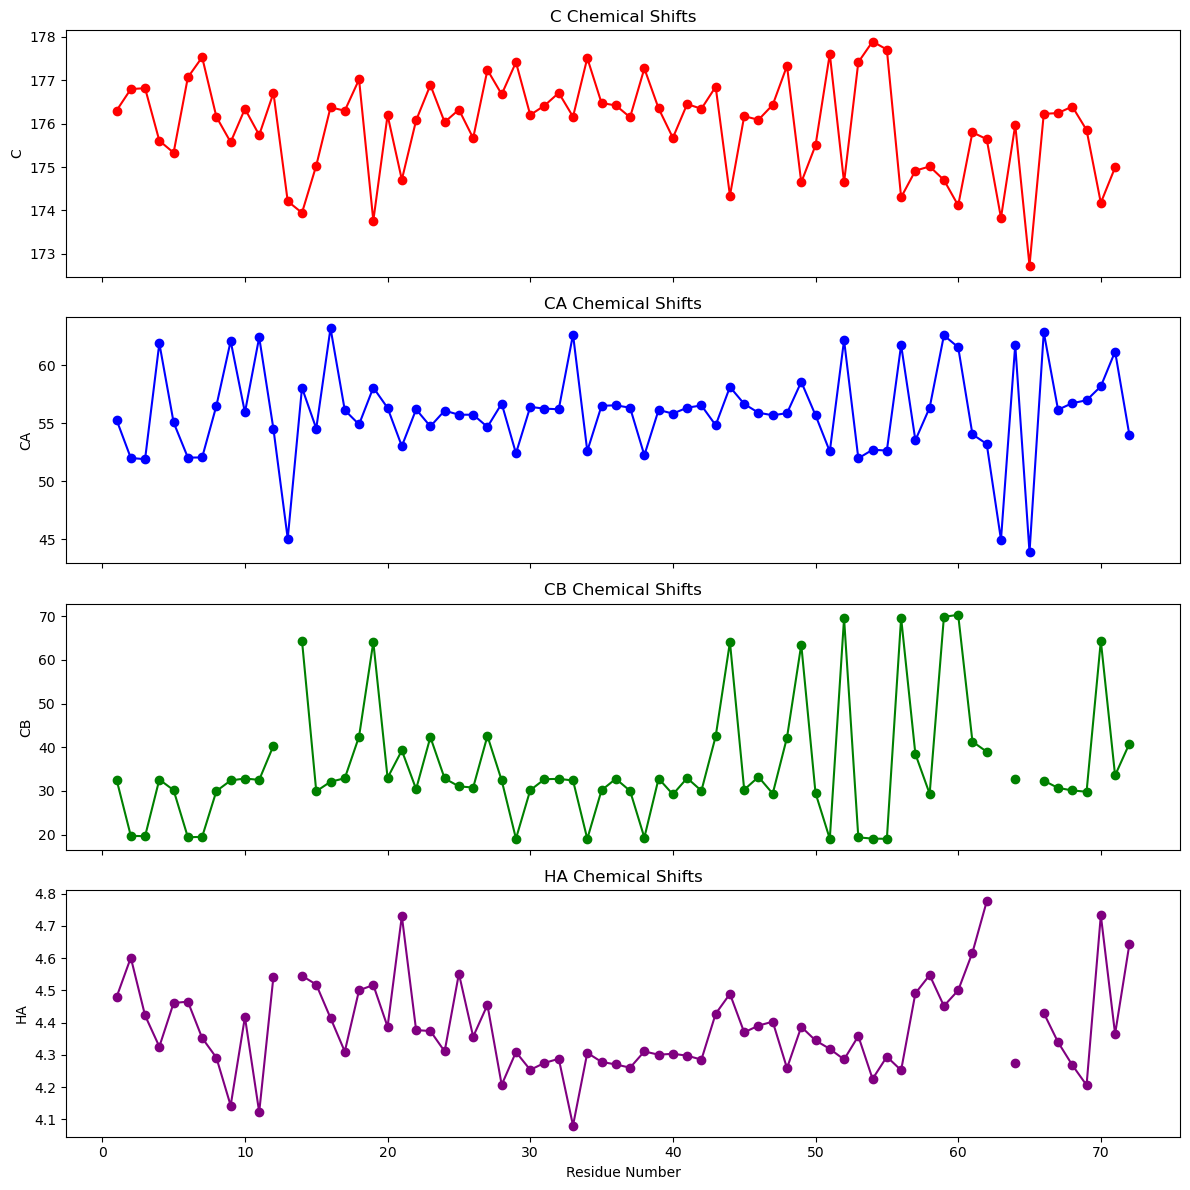

In [3]:
ID = 15

for system in systems:
    if system['ID'] == ID:
        dataFolder = '../../Data/Simulations/' + system['path']
        print(system['SYSTEM'])
        print(system['TRJ'])

# Example input data (you can replace this with reading from YAML or JSON if needed)

chemical_shifts_file = dataFolder + 'chemical_shifts_sparta.yaml'

with open(chemical_shifts_file, "r") as file:
    data = yaml.safe_load(file)   

# Extract residue numbers
residues = sorted(data.keys())

# Extract values for each nucleus of interest
C_values = [data[res].get("C", float("nan")) for res in residues]
CA_values = [data[res].get("CA", float("nan")) for res in residues]
CB_values = [data[res].get("CB", float("nan")) for res in residues]
HA_values = [data[res].get("HA", float("nan")) for res in residues]

# Plotting
fig, axs = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axs[0].plot(residues, C_values, marker='o', color='red')
axs[0].set_ylabel("C")
axs[0].set_title("C Chemical Shifts")

axs[1].plot(residues, CA_values, marker='o', color='blue')
axs[1].set_ylabel("CA")
axs[1].set_title("CA Chemical Shifts")

axs[2].plot(residues, CB_values, marker='o', color='green')
axs[2].set_ylabel("CB")
axs[2].set_title("CB Chemical Shifts")

axs[3].plot(residues, HA_values, marker='o', color='purple')
axs[3].set_ylabel("HA")
axs[3].set_title("HA Chemical Shifts")
axs[3].set_xlabel("Residue Number")

plt.tight_layout()
plt.show()


ChiZ1-64
[['replica_03_AMBER99SBWS_md_1500ns.xtc']]
ChiZ1-64
[['replica_03_AMBER03WS_md_1500ns.xtc']]


KeyError: '1'

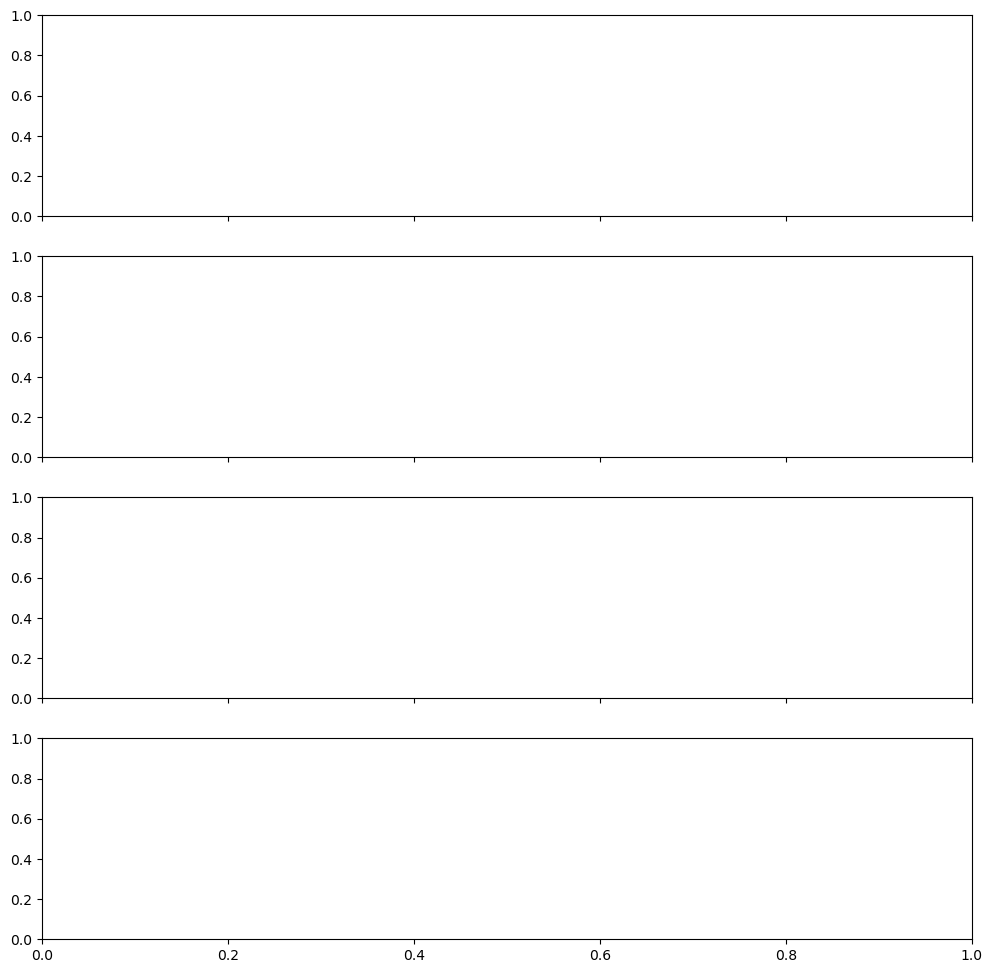

In [4]:
IDs = [2, 3]

files = []

for system in systems:
    if system['ID'] in IDs:
        dataFolder = '../../Data/Simulations/' + system['path']
        chemical_shifts_file = dataFolder + 'chemical_shifts_sparta.yaml'
        files.append(chemical_shifts_file)
        print(system['SYSTEM'])
        print(system['TRJ'])

# List of files to compare
#files = [
#    dataFolder + "chemical_shifts_sparta.yaml",
#    dataFolder + "chemical_shifts_other.yaml",
#    dataFolder + "chemical_shifts_third.yaml",
#]

# Colors for different datasets
colors = ["red", "blue", "green", "purple", "orange", "brown"]

# Nuclei of interest
nuclei = ["C", "CA", "CB", "HA"]

# Create subplots (1 per nucleus)
fig, axs = plt.subplots(len(nuclei), 1, figsize=(12, 12), sharex=True)

for file_idx, filename in enumerate(files):
    with open(filename, "r") as f:
        raw_data = yaml.safe_load(f)

    # Convert keys to int → value dicts
    data = {int(k): v for k, v in raw_data.items()}

    # Residues sorted as integers
    residues = sorted(data.keys())
    ## Extract residues as integers
    #residues = sorted(map(int, data.keys()))

    for ax, nucleus in zip(axs, nuclei):
        values = [data[str(res)].get(nucleus, float("nan")) for res in residues]
        ax.plot(
            residues,
            values,
            marker="o",
            linewidth=1,
            label=os.path.basename(filename).replace(".yaml", ""),
            color=colors[file_idx % len(colors)]
        )
        ax.set_ylabel(nucleus)
        ax.set_title(f"{nucleus} Chemical Shifts")
        ax.grid(True, linestyle="--", alpha=0.6)

# Common X label
axs[-1].set_xlabel("Residue Number")

# Add legends (to the first subplot, or all if you prefer)
axs[0].legend()

plt.tight_layout()
plt.show()


1
KRS1-72
[['replica_02_DESAMBER_md_2000ns.xtc']]
2
ChiZ1-64
[['replica_03_AMBER99SBWS_md_1500ns.xtc']]
3
ChiZ1-64
[['replica_03_AMBER03WS_md_1500ns.xtc']]
4
ChiZ1-64
[['replica_04_AMBER99SBWS_md_1500ns.xtc']]
5
KRS1-72
[['replica_01_DESAMBER_md_2000ns.xtc']]
6
ChiZ1-64
[['replica_05_AMBER03WS_md_1500ns.xtc']]
7
ChiZ1-64
[['replica_03_CHARMM36M_md_1500ns.xtc']]
8
KRS1-72
[['replica_05_CHARMM36M_md_2000ns.xtc']]
9
KRS1-72
[['replica_01_CHARMM36M_md_2000ns.xtc']]
10
ChiZ1-64
[['replica_04_AMBER03WS_md_1500ns.xtc']]
11
ChiZ1-64
[['replica_02_AMBER99SB-DISP_md_1500ns.xtc']]
12
ChiZ1-64
[['replica_05_CHARMM36M_md_1500ns.xtc']]
13
KRS1-72
[['replica_04_DESAMBER_md_2000ns.xtc']]
14
KRS1-72
[['replica_04_AMBER03WS_md_2000ns.xtc']]
15
KRS1-72
[['replica_05_DESAMBER_md_2000ns.xtc']]
16
ChiZ1-64
[['replica_01_DESAMBER_md_1500ns.xtc']]
17
KRS1-72
[['replica_02_CHARMM36M_md_2000ns.xtc']]
18
ChiZ1-64
[['replica_02_CHARMM36M_md_1500ns.xtc']]
19
ChiZ1-64
[['replica_03_AMBER99SB-DISP_md_1500ns.xtc']]
2

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


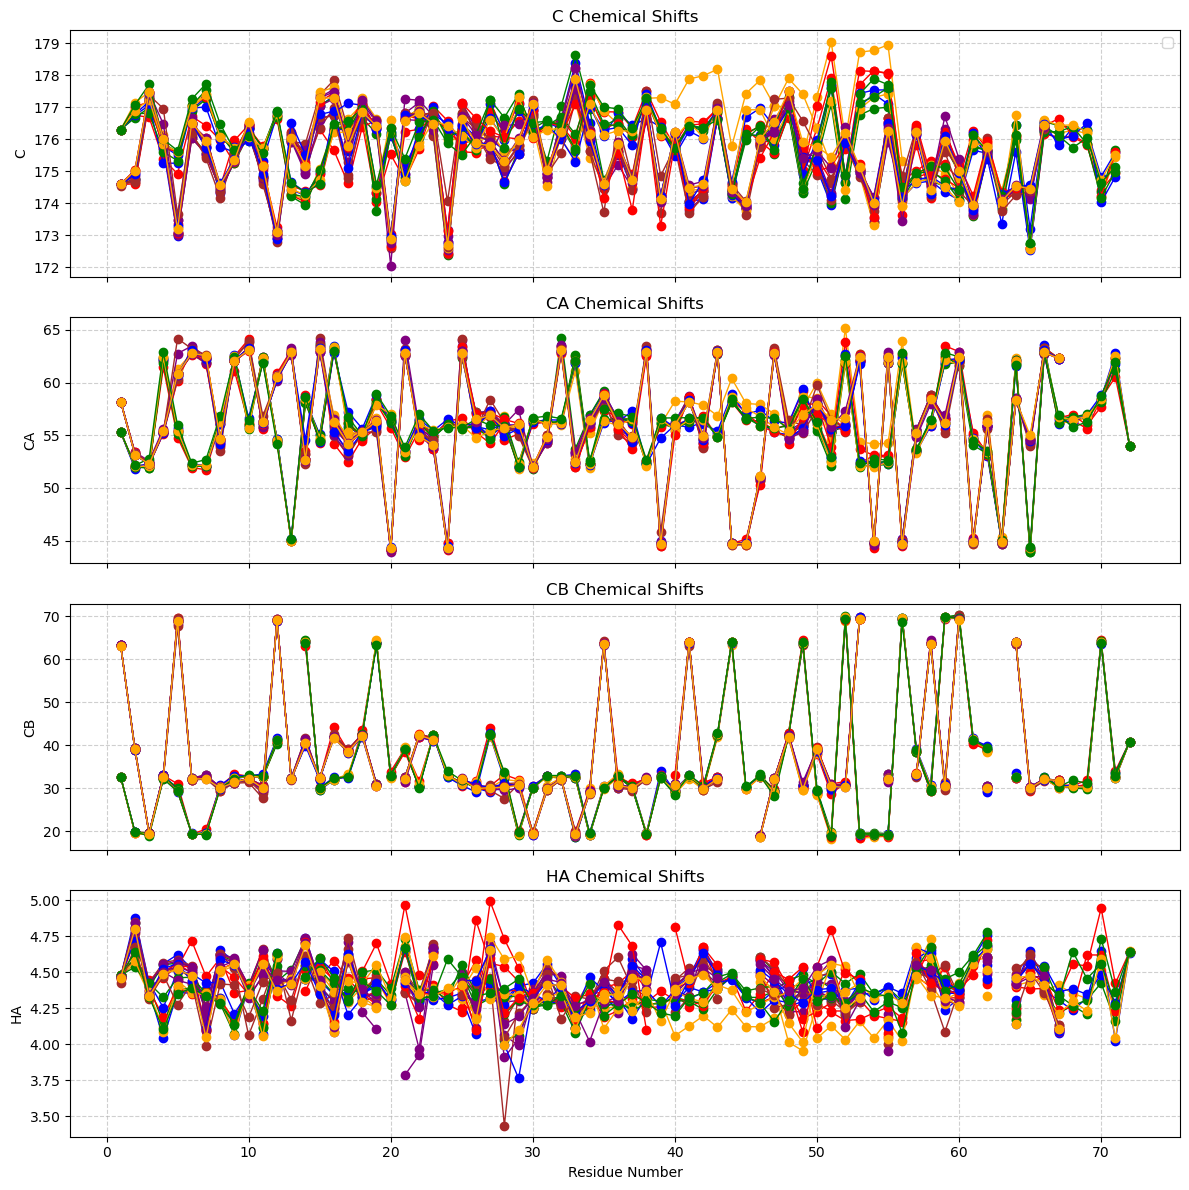

In [5]:
IDs = list(range(1, 25))
IDs.remove(23)

files = []

for system in systems:
    if system['ID'] in IDs:
        dataFolder = '../../Data/Simulations/' + system['path']
        chemical_shifts_file = dataFolder + 'chemical_shifts_sparta.yaml'
        files.append(chemical_shifts_file)
        print(system['ID'])
        print(system['SYSTEM'])
        print(system['TRJ'])

# Colors for different datasets
colors = ["red", "blue", "green", "purple", "orange", "brown"]

# Nuclei of interest
nuclei = ["C", "CA", "CB", "HA"]

# Create subplots (1 per nucleus)
fig, axs = plt.subplots(len(nuclei), 1, figsize=(12, 12), sharex=True)

for file_idx, filename in enumerate(files):
    with open(filename, "r") as f:
        raw_data = yaml.safe_load(f)

    # Convert keys to int → value dicts
    data = {int(k): v for k, v in raw_data.items()}

    # Residues sorted as integers
    residues = sorted(data.keys())

    for ax, nucleus in zip(axs, nuclei):
        values = [data.get(res, {}).get(nucleus, float("nan")) for res in residues]
        ax.plot(
            residues,
            values,
            marker="o",
            linewidth=1,
            #label=os.path.basename(filename).replace(".yaml", ""),
            color=colors[file_idx % len(colors)]
        )
        ax.set_ylabel(nucleus)
        ax.set_title(f"{nucleus} Chemical Shifts")
        ax.grid(True, linestyle="--", alpha=0.6)

# Common X label
axs[-1].set_xlabel("Residue Number")

# Add legends (to the first subplot, or all if you prefer)
axs[0].legend()

plt.tight_layout()
plt.show()


KRS1-72
[['replica_02_DESAMBER_md_2000ns.xtc']]
ChiZ1-64
[['replica_03_AMBER99SBWS_md_1500ns.xtc']]
ChiZ1-64
[['replica_03_AMBER03WS_md_1500ns.xtc']]
ChiZ1-64
[['replica_04_AMBER99SBWS_md_1500ns.xtc']]
KRS1-72
[['replica_01_DESAMBER_md_2000ns.xtc']]
ChiZ1-64
[['replica_05_AMBER03WS_md_1500ns.xtc']]
ChiZ1-64
[['replica_03_CHARMM36M_md_1500ns.xtc']]
KRS1-72
[['replica_05_CHARMM36M_md_2000ns.xtc']]
KRS1-72
[['replica_01_CHARMM36M_md_2000ns.xtc']]
ChiZ1-64
[['replica_04_AMBER03WS_md_1500ns.xtc']]
ChiZ1-64
[['replica_02_AMBER99SB-DISP_md_1500ns.xtc']]
ChiZ1-64
[['replica_05_CHARMM36M_md_1500ns.xtc']]
KRS1-72
[['replica_04_DESAMBER_md_2000ns.xtc']]
KRS1-72
[['replica_04_AMBER03WS_md_2000ns.xtc']]
KRS1-72
[['replica_05_DESAMBER_md_2000ns.xtc']]
ChiZ1-64
[['replica_01_DESAMBER_md_1500ns.xtc']]
KRS1-72
[['replica_02_CHARMM36M_md_2000ns.xtc']]
ChiZ1-64
[['replica_02_CHARMM36M_md_1500ns.xtc']]
ChiZ1-64
[['replica_03_AMBER99SB-DISP_md_1500ns.xtc']]
ChiZ1-64
[['replica_03_DESAMBER_md_1500ns.xtc']]


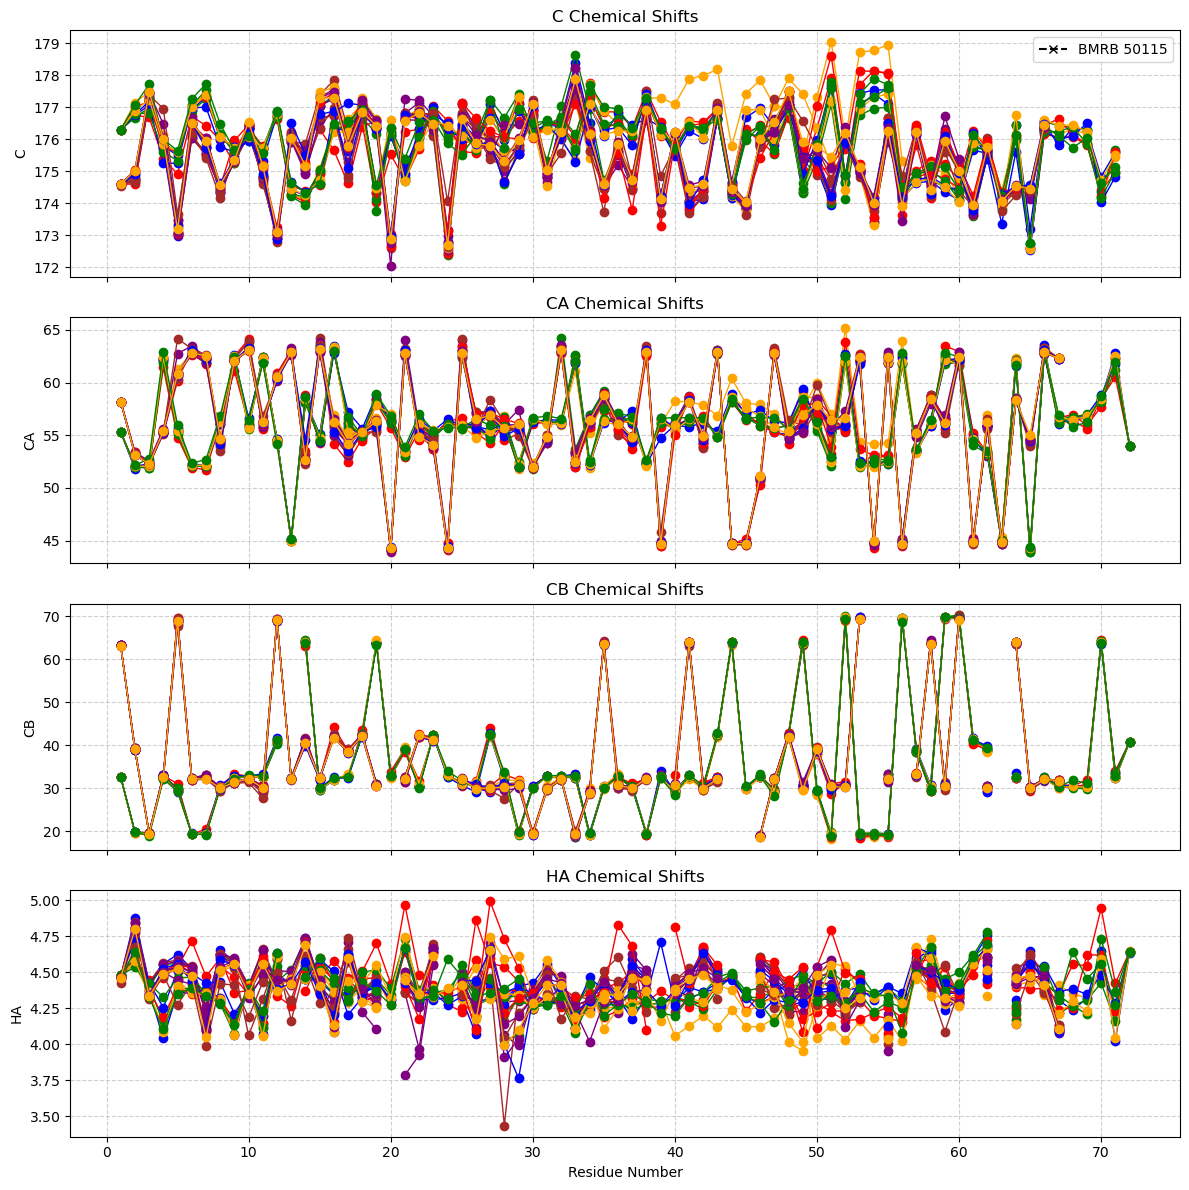

In [6]:
import yaml
import matplotlib.pyplot as plt
import os
import requests
import math

# -------------------
# 1. Your simulations
# -------------------

IDs = list(range(1, 25))
IDs.remove(23)

#IDs = [2, 3]
files = []
sim_residues_all = set()

for system in systems:
    if system['ID'] in IDs:
        dataFolder = '../../Data/Simulations/' + system['path']
        chemical_shifts_file = dataFolder + 'chemical_shifts_sparta.yaml'
        files.append(chemical_shifts_file)
        print(system['SYSTEM'])
        print(system['TRJ'])
        # Collect all residue numbers
        with open(chemical_shifts_file) as f:
            raw = yaml.safe_load(f)
            sim_residues_all.update(int(k) for k in raw.keys())

colors = ["red", "blue", "green", "purple", "orange", "brown"]
nuclei = ["C", "CA", "CB", "HA"]

# ------------------------
# 2. Download NMR-STAR file
# ------------------------
bmrb_url = "https://bmrb.io/ftp/pub/bmrb/entry_directories/bmr50115/bmr50115_3.str"#https://bmrb.io/_download/entry/50115/bmr50115.str"
bmrb_local_file = "bmr50115.str"

if not os.path.exists(bmrb_local_file):
    print("Downloading BMRB NMR-STAR file...")
    r = requests.get(bmrb_url)
    r.raise_for_status()
    with open(bmrb_local_file, "wb") as f:
        f.write(r.content)
    print("Download complete.")

# ------------------------
# 3. Parse NMR-STAR file
# ------------------------

exp_data = parse_star_file(bmrb_local_file)
# Filter to simulation residues
exp_data_filtered = {res: atoms for res, atoms in exp_data.items() if res in sim_residues_all}
exp_residues = sorted(exp_data_filtered.keys())

print("Experimental residues:", exp_residues[:10])
print("Example residue data:", {r: exp_data_filtered[r] for r in exp_residues[:5]})

# ------------------------
# 4. Plotting
# ------------------------
fig, axs = plt.subplots(len(nuclei), 1, figsize=(12, 12), sharex=True)

# Simulated data
for file_idx, filename in enumerate(files):
    with open(filename, "r") as f:
        raw = yaml.safe_load(f)
    sim_data = {int(k): v for k, v in raw.items()}
    residues = sorted(sim_data.keys())

    for ax, nucleus in zip(axs, nuclei):
        values = [sim_data.get(r, {}).get(nucleus, math.nan) for r in residues]
        ax.plot(
            residues,
            values,
            marker="o",
            linewidth=1,
            #label=os.path.basename(filename).replace(".yaml", ""),
            color=colors[file_idx % len(colors)]
        )
        ax.set_ylabel(nucleus)
        ax.set_title(f"{nucleus} Chemical Shifts")
        ax.grid(True, linestyle="--", alpha=0.6)

# Experimental data overlay
for ax, nucleus in zip(axs, nuclei):
    vals_exp = [exp_data_filtered.get(r, {}).get(nucleus, math.nan) for r in exp_residues]
    ax.plot(
        exp_residues,
        vals_exp,
        marker="x",
        linestyle="--",
        color="black",
        label="BMRB 50115"
    )

axs[-1].set_xlabel("Residue Number")
axs[0].legend()
plt.tight_layout()
plt.show()


In [7]:
import math
import numpy as np

# List of nuclei to consider
nuclei = ["C", "CA", "CB", "HA"]

# Example: simulations is a list of tuples [(sim_name, sim_data_dict), ...]
# sim_data_dict: {residue_number: {"C": val, "CA": val, ...}, ...}
# exp_data_filtered: {residue_number: {"C": val, "CA": val, ...}, ...}

# Get the residues present in both simulation and experiment
common_residues = sorted(exp_data_filtered.keys())

# Iterate over all simulations
for sim_name, sim_data in simulations:
    rmsd_vals = compute_rmsd_chemical_shift(sim_data, exp_data_filtered, nuclei, common_residues)
    print(f"RMSDs for {sim_name}:")
    for nuc, rmsd in rmsd_vals.items():
        if rmsd is not None:
            print(f"  {nuc}: {rmsd:.2f} ppm")
        else:
            print(f"  {nuc}: N/A")
    avg_rmsd = np.mean([v for v in rmsd_vals.values() if v is not None])
    print(f"  Average RMSD: {avg_rmsd:.2f} ppm\n")


NameError: name 'simulations' is not defined

In [3]:
import yaml
import requests
import os
import numpy as np

# ------------------------
# Simulation files setup
# ------------------------
#IDs = [2, 3]  # simulation IDs to process
IDs = list(range(1, 25))
IDs.remove(23)

sim_files = []
sim_names = []

sim_residues_all = set()
for system in systems:
    if system['ID'] in IDs:
        dataFolder = '../../Data/Simulations/' + system['path']
        sim_file = os.path.join(dataFolder, 'chemical_shifts_sparta.yaml')
        sim_files.append(sim_file)
        sim_names.append(system['SYSTEM'])
        with open(sim_file) as f:
            raw = yaml.safe_load(f)
            sim_residues_all.update(int(k) for k in raw.keys())

# ------------------------
# Download BMRB file
# ------------------------
bmrb_url = "https://bmrb.io/_download/entry/50115/bmr50115.str"
bmrb_local_file = "bmr50115.str"

if not os.path.exists(bmrb_local_file):
    print("Downloading BMRB NMR-STAR file...")
    r = requests.get(bmrb_url)
    r.raise_for_status()
    with open(bmrb_local_file, "wb") as f:
        f.write(r.content)
    print("Download complete.")

# ------------------------
# Parse NMR-STAR file
# ------------------------

exp_data = parse_star_file(bmrb_local_file)
# Only residues present in simulation
exp_data_filtered = {res: atoms for res, atoms in exp_data.items() if res in sim_residues_all}
exp_residues = sorted(exp_data_filtered.keys())

# ------------------------
# Calculate RMSDs
# ------------------------
nuclei = ["C", "CA", "CB", "HA"]


# Process each simulation
for sim_file, sim_name in zip(sim_files, sim_names):
    with open(sim_file) as f:
        raw = yaml.safe_load(f)
    sim_data = {int(k): v for k, v in raw.items()}
    rmsd_vals = compute_rmsd_chemical_shift(sim_data, exp_data_filtered, nuclei, exp_residues)
    print(f"RMSDs for {sim_file}:")
    for nuc, rmsd in rmsd_vals.items():
        if rmsd is not None:
            print(f"  {nuc}: {rmsd:.2f} ppm")
        else:
            print(f"  {nuc}: N/A")
    avg_rmsd = np.mean([v for v in rmsd_vals.values() if v is not None])
    print(f"  Average RMSD: {avg_rmsd:.2f} ppm\n")


RMSDs for ../../Data/Simulations/f8e/81d/f8e81d87d1c190bc5ec45084165e12dec9ed5d13/c26e9d4317436c590fe19ecff68b36cdcc8508d9/chemical_shifts_sparta.yaml:
  C: 1.85 ppm
  CA: 7.02 ppm
  CB: 18.02 ppm
  HA: 3.95 ppm
  Average RMSD: 7.71 ppm

RMSDs for ../../Data/Simulations/cdf/798/cdf7987102d6473c8ad0ab8a4f7c384b16b4cb5b/bab80edfd37192c8d2df12c5865f2c658d21a7d1/chemical_shifts_sparta.yaml:
  C: 0.38 ppm
  CA: 0.45 ppm
  CB: 0.40 ppm
  HA: 3.88 ppm
  Average RMSD: 1.28 ppm

RMSDs for ../../Data/Simulations/082/ab4/082ab4aadd4dcb08f1f8b5c27c7f7c4e0c592c55/b6b68bfc7e719eafc21ce452ff6f44d214769ce1/chemical_shifts_sparta.yaml:
  C: 0.50 ppm
  CA: 0.55 ppm
  CB: 0.38 ppm
  HA: 3.89 ppm
  Average RMSD: 1.33 ppm

RMSDs for ../../Data/Simulations/ead/ea4/eadea42c0c2e4be95ab0fdddf1bb8cb8f37f88bc/2147ba4d757f0218ab957ac602c5289659a36a26/chemical_shifts_sparta.yaml:
  C: 0.42 ppm
  CA: 0.47 ppm
  CB: 0.42 ppm
  HA: 3.91 ppm
  Average RMSD: 1.30 ppm

RMSDs for ../../Data/Simulations/179/10c/17910cbc30

ChiZ1-64
[['replica_03_AMBER99SBWS_md_1500ns.xtc']]
../../Data/Experiments/spin_relaxation/BMRBid50115/bmr50115.str
Experimental residues: [2, 3, 4, 5, 6, 7, 8, 10, 11, 12]
Example residue data: {2: {'C': 174.939, 'CA': 53.232, 'CB': 39.112}, 3: {'HA': 8.428, 'C': 177.635, 'CA': 52.819, 'CB': 19.15}, 4: {'HA': 8.391, 'C': 176.172, 'CA': 55.336, 'CB': 32.786}, 5: {'HA': 8.182, 'C': 172.665, 'CA': 59.958, 'CB': 69.782}, 6: {'C': 176.799, 'CA': 63.052, 'CB': 32.154}}


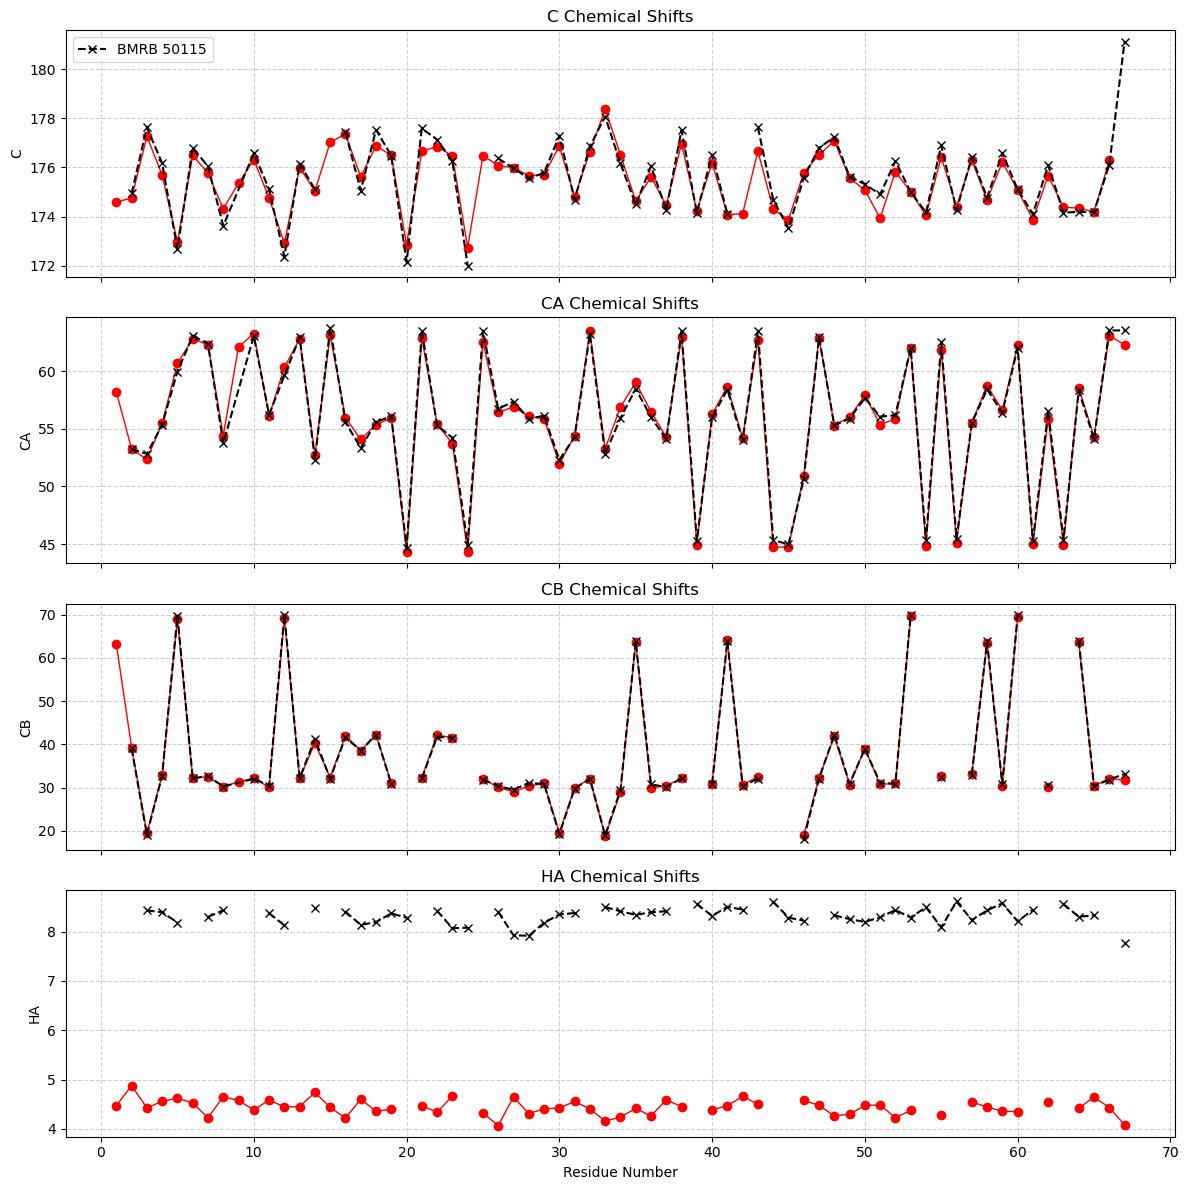

In [4]:
import yaml
import matplotlib.pyplot as plt
import os
import requests
import math

# -------------------
# 1. Your simulations
# -------------------

#IDs = list(range(1, 25))
#IDs.remove(23)

#IDs = [2, 3]
IDs = [2]
files = []
BMRBid = []
sim_residues_all = set()

for system in systems:
    if system['ID'] in IDs:
        dataFolder = '../../Data/Simulations/' + system['path']
        chemical_shifts_file = dataFolder + 'chemical_shifts_sparta.yaml'
        files.append(chemical_shifts_file)
        print(system['SYSTEM'])
        print(system['TRJ'])
        # Collect all residue numbers
        with open(chemical_shifts_file) as f:
            raw = yaml.safe_load(f)
            sim_residues_all.update(int(k) for k in raw.keys())

        BMRBid.append(system['EXPERIMENT']['spin_relaxation']['path'][0].replace("BMRBid", "", 1))
        

colors = ["red", "blue", "green", "purple", "orange", "brown"]
nuclei = ["C", "CA", "CB", "HA"]

# ------------------------
# 2. Download NMR-STAR file
# ------------------------



bmrb_url = "https://bmrb.io/ftp/pub/bmrb/entry_directories/bmr50115/bmr50115_3.str"#https://bmrb.io/_download/entry/50115/bmr50115.str"
bmrb_local_file = "bmr50115.str"

bmrb_url = "https://bmrb.io/ftp/pub/bmrb/entry_directories/bmr" + BMRBid[0] +"/bmr" + BMRBid[0] + "_3.str"
exp_data_path = '../../Data/Experiments/spin_relaxation/BMRBid' + BMRBid[0]
bmrb_local_file = exp_data_path + "/bmr" + BMRBid[0] + ".str"



if not os.path.exists(bmrb_local_file):
    print("Downloading BMRB NMR-STAR file...")
    r = requests.get(bmrb_url)
    r.raise_for_status()
    with open(bmrb_local_file, "wb") as f:
        f.write(r.content)
    print("Download complete.")

# ------------------------
# 3. Parse NMR-STAR file
# ------------------------

exp_data = parse_star_file(bmrb_local_file)
# Filter to simulation residues

print(bmrb_local_file)

exp_data_filtered = {res: atoms for res, atoms in exp_data.items() if res in sim_residues_all}
exp_residues = sorted(exp_data_filtered.keys())

print("Experimental residues:", exp_residues[:10])
print("Example residue data:", {r: exp_data_filtered[r] for r in exp_residues[:5]})

# ------------------------
# 4. Plotting
# ------------------------
fig, axs = plt.subplots(len(nuclei), 1, figsize=(12, 12), sharex=True)

# Simulated data
for file_idx, filename in enumerate(files):
    with open(filename, "r") as f:
        raw = yaml.safe_load(f)
    sim_data = {int(k): v for k, v in raw.items()}
    residues = sorted(sim_data.keys())

    for ax, nucleus in zip(axs, nuclei):
        values = [sim_data.get(r, {}).get(nucleus, math.nan) for r in residues]
        ax.plot(
            residues,
            values,
            marker="o",
            linewidth=1,
            #label=os.path.basename(filename).replace(".yaml", ""),
            color=colors[file_idx % len(colors)]
        )
        ax.set_ylabel(nucleus)
        ax.set_title(f"{nucleus} Chemical Shifts")
        ax.grid(True, linestyle="--", alpha=0.6)

# Experimental data overlay
for ax, nucleus in zip(axs, nuclei):
    vals_exp = [exp_data_filtered.get(r, {}).get(nucleus, math.nan) for r in exp_residues]
    ax.plot(
        exp_residues,
        vals_exp,
        marker="x",
        linestyle="--",
        color="black",
        label="BMRB 50115"
    )

axs[-1].set_xlabel("Residue Number")
axs[0].legend()
plt.tight_layout()
plt.show()
